# Task 4.2 (Part A) — YOLOv5 on Brain Tumor Dataset

**Dataset:** Brain Tumor Detection (YOLO format)  
**Classes:** negative (0), positive (1)  
**Training:** 500 images (subset), 40 epochs

## Step 1: Install Dependencies

In [2]:
!pip install -q torch torchvision
!git clone https://github.com/ultralytics/yolov5.git
!pip install -q -r yolov5/requirements.txt

fatal: destination path 'yolov5' already exists and is not an empty directory.


In [3]:
import os
import shutil
import random
import yaml
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from glob import glob

## Step 2: Prepare Dataset (500 Image Subset)

In [4]:
# Paths — update BASE_DIR to where your brain-tumor folder is
BASE_DIR = 'brain-tumor'  # relative to this notebook

# Create a 500-image subset for training
SUBSET_DIR = 'brain_tumor_subset'
os.makedirs(f'{SUBSET_DIR}/images/train', exist_ok=True)
os.makedirs(f'{SUBSET_DIR}/images/val', exist_ok=True)
os.makedirs(f'{SUBSET_DIR}/labels/train', exist_ok=True)
os.makedirs(f'{SUBSET_DIR}/labels/val', exist_ok=True)

# Get all training images and pick 500
train_images = sorted(glob(f'{BASE_DIR}/images/train/*.jpg'))
random.seed(42)
selected = random.sample(train_images, min(500, len(train_images)))

# Copy selected training images and labels
for img_path in selected:
    name = os.path.basename(img_path)
    label_name = name.replace('.jpg', '.txt')
    shutil.copy(img_path, f'{SUBSET_DIR}/images/train/{name}')
    label_path = f'{BASE_DIR}/labels/train/{label_name}'
    if os.path.exists(label_path):
        shutil.copy(label_path, f'{SUBSET_DIR}/labels/train/{label_name}')

# Copy ALL validation images and labels
for img_path in glob(f'{BASE_DIR}/images/val/*.jpg'):
    name = os.path.basename(img_path)
    label_name = name.replace('.jpg', '.txt')
    shutil.copy(img_path, f'{SUBSET_DIR}/images/val/{name}')
    label_path = f'{BASE_DIR}/labels/val/{label_name}'
    if os.path.exists(label_path):
        shutil.copy(label_path, f'{SUBSET_DIR}/labels/val/{label_name}')

print(f'Training images: {len(os.listdir(f"{SUBSET_DIR}/images/train"))}')
print(f'Validation images: {len(os.listdir(f"{SUBSET_DIR}/images/val"))}')

Training images: 0
Validation images: 0


**Interpretation:** We select 500 random training images (as per assignment requirement to cap at 500) while keeping all 223 validation images. Labels are in YOLO format (class, center_x, center_y, width, height — all normalized).

## Step 3: Create Dataset YAML

In [5]:
# Create YAML config for YOLO
data_yaml = {
    'path': os.path.abspath(SUBSET_DIR),
    'train': 'images/train',
    'val': 'images/val',
    'nc': 2,
    'names': ['negative', 'positive']
}

with open('yolov5_training.yaml', 'w') as f:
    yaml.dump(data_yaml, f)

print('Dataset YAML created:')
print(yaml.dump(data_yaml))

Dataset YAML created:
names:
- negative
- positive
nc: 2
path: /Users/hiteshprajapathi/Desktop/brain_tumor/yolov5_model/brain_tumor_subset
train: images/train
val: images/val



## Step 4: Visualize Some Training Images

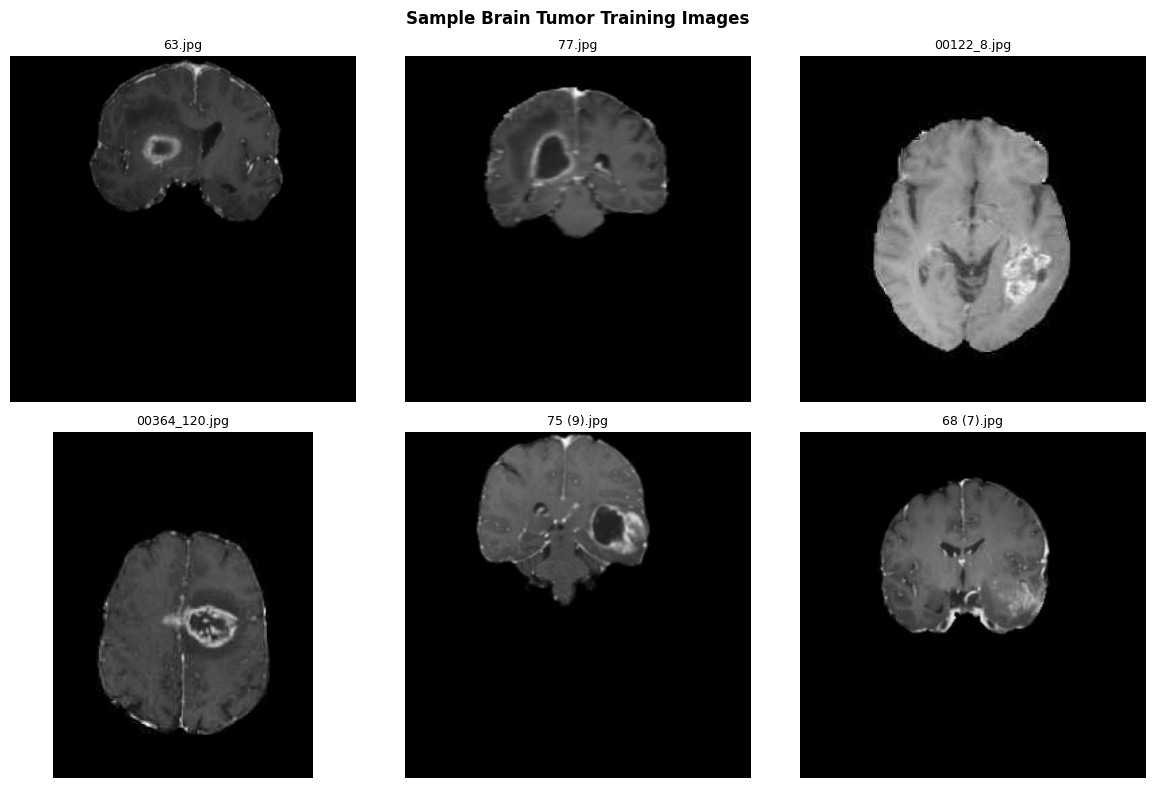

In [10]:
sample_imgs = glob(f'/Users/hiteshprajapathi/Desktop/brain_tumor/brain_tumor_subset/images/train/*.jpg')[:6]

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for i, img_path in enumerate(sample_imgs):
    ax = axes[i//3][i%3]
    img = mpimg.imread(img_path)
    ax.imshow(img, cmap='gray')
    ax.set_title(os.path.basename(img_path), fontsize=9)
    ax.axis('off')
plt.suptitle('Sample Brain Tumor Training Images', fontweight='bold')
plt.tight_layout()
plt.savefig('yolov5_sample_images.png', dpi=100)
plt.show()

**Interpretation:** These are brain MRI scans. The model needs to detect and localize tumor regions (positive class) or confirm no tumor (negative class).

## Step 5: Train YOLOv5

## Visualize Training Scans with Bounding Boxes

Before training, let's visualize some brain tumor scans from the training dataset with their ground-truth bounding box annotations overlaid.

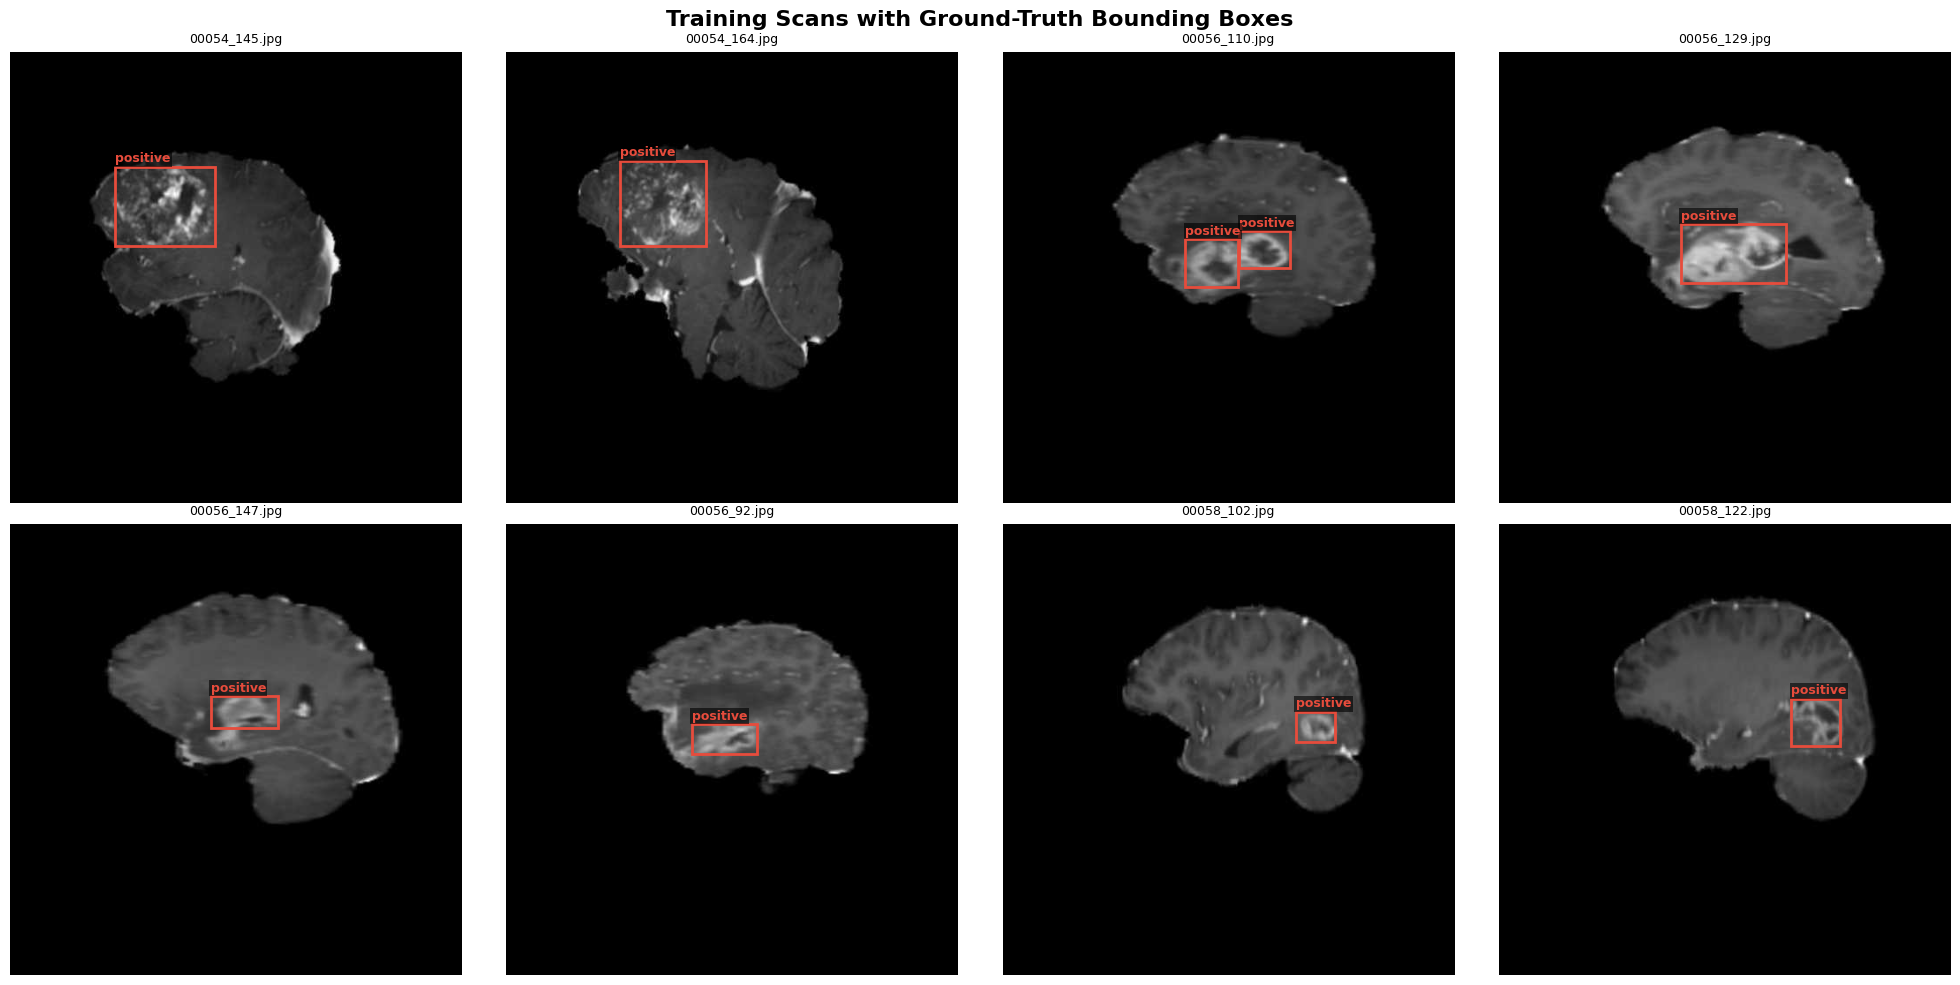

Visualized 8 scans with tumor bounding boxes
Total training images with annotations: 489


In [7]:
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from glob import glob
import os

# Use absolute path to avoid working directory issues
DATASET = '/Users/hiteshprajapathi/Desktop/brain_tumor/brain_tumor_subset'

# Get training images that have labels (positive samples with tumors)
label_files = sorted(glob(f'{DATASET}/labels/train/*.txt'))
positive_labels = [f for f in label_files if os.path.getsize(f) > 0]

CLASS_NAMES = ['negative', 'positive']
COLORS = ['#2ecc71', '#e74c3c']  # green for negative, red for positive

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
fig.suptitle('Training Scans with Ground-Truth Bounding Boxes', fontsize=16, fontweight='bold')

for idx, label_path in enumerate(positive_labels[:8]):
    ax = axes[idx // 4][idx % 4]
    
    # Load corresponding image
    img_name = os.path.basename(label_path).replace('.txt', '.jpg')
    img_path = f'{DATASET}/images/train/{img_name}'
    img = cv2.imread(img_path)
    if img is None:
        ax.set_title(f'{img_name} (not found)', fontsize=9, color='red')
        ax.axis('off')
        continue
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    
    ax.imshow(img)
    
    # Draw bounding boxes from label file
    with open(label_path) as f:
        for line in f.readlines():
            parts = line.strip().split()
            cls_id = int(parts[0])
            x_center, y_center, bw, bh = [float(v) for v in parts[1:]]
            
            # Convert from YOLO format (normalized) to pixel coordinates
            x1 = int((x_center - bw / 2) * w)
            y1 = int((y_center - bh / 2) * h)
            box_w = int(bw * w)
            box_h = int(bh * h)
            
            rect = patches.Rectangle((x1, y1), box_w, box_h,
                                     linewidth=2, edgecolor=COLORS[cls_id],
                                     facecolor='none')
            ax.add_patch(rect)
            ax.text(x1, y1 - 5, CLASS_NAMES[cls_id],
                    color=COLORS[cls_id], fontsize=9, fontweight='bold',
                    bbox=dict(facecolor='black', alpha=0.6, edgecolor='none', pad=1))
    
    ax.set_title(img_name, fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()
print(f'Visualized {min(8, len(positive_labels))} scans with tumor bounding boxes')
print(f'Total training images with annotations: {len(positive_labels)}')

In [7]:
!python yolov5/train.py \
    --img 640 \
    --batch 16 \
    --epochs 30 \
    --data yolov5_training.yaml \
    --weights yolov5s.pt \
    --device mps \
    --name brain_tumor_v5 \
    --project runs \
    --exist-ok

train: weights=yolov5s.pt, cfg=, data=brain_tumor_yolov5.yaml, hyp=yolov5/data/hyps/hyp.scratch-low.yaml, epochs=30, batch_size=16, imgsz=640, rect=False, resume=False, nosave=False, noval=False, noautoanchor=False, noplots=False, evolve=None, evolve_population=yolov5/data/hyps, resume_evolve=None, bucket=, cache=None, image_weights=False, device=mps, multi_scale=False, single_cls=False, optimizer=SGD, sync_bn=False, workers=8, project=runs/yolov5, name=brain_tumor_v5, exist_ok=True, quad=False, cos_lr=False, label_smoothing=0.0, patience=100, freeze=[0], save_period=-1, seed=0, local_rank=-1, entity=None, upload_dataset=False, bbox_interval=-1, artifact_alias=latest, ndjson_console=False, ndjson_file=False
github: up to date with https://github.com/ultralytics/yolov5 ✅
YOLOv5 🚀 v7.0-460-g3fb11111 Python-3.11.14 torch-2.10.0 MPS

hyperparameters: lr0=0.01, lrf=0.01, momentum=0.937, weight_decay=0.0005, warmup_epochs=3.0, warmup_momentum=0.8, warmup_bias_lr=0.1, box=0.05, cls=0.5, cls_p

**Interpretation:** We train YOLOv5s (small variant) for 30 epochs at 640×640 resolution using MPS (Apple Metal GPU). The model uses pretrained COCO weights as a starting point (transfer learning), which speeds up convergence on our small dataset.

## Step 6: Plot Training Results

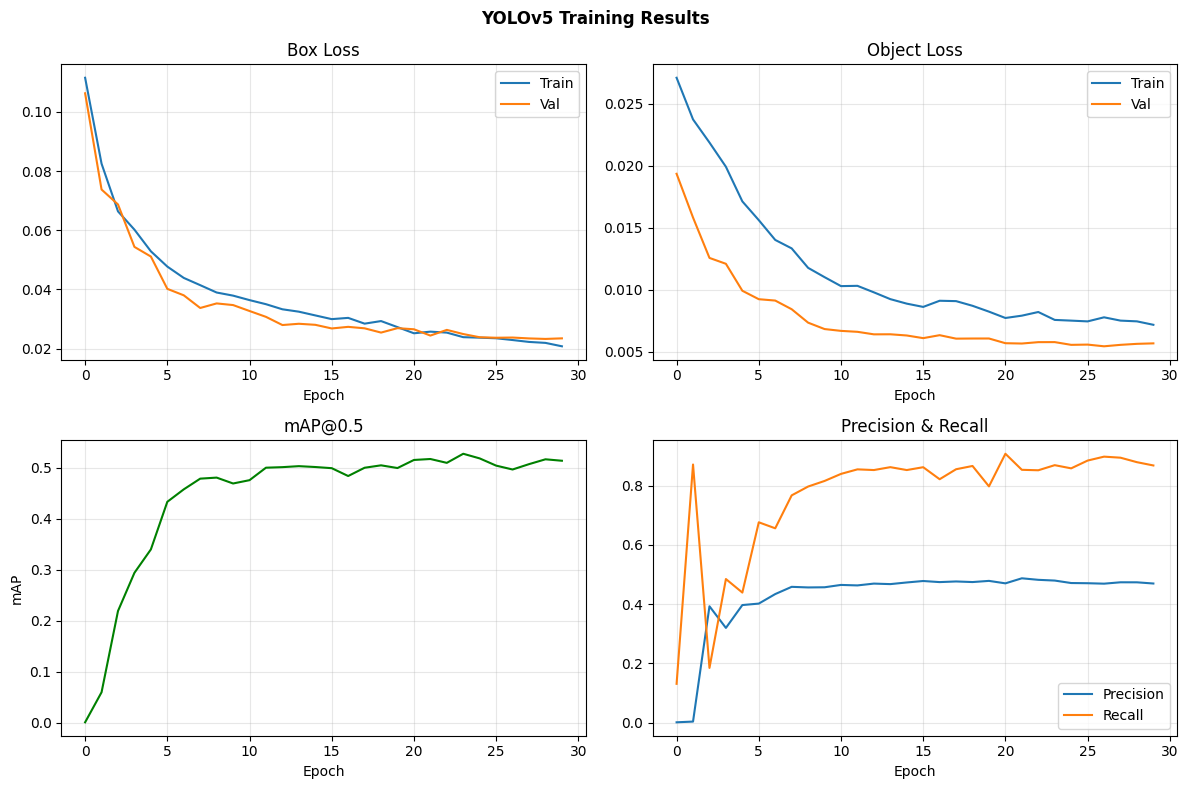


Best mAP@0.5: 0.5273
Best Precision: 0.4869
Best Recall: 0.9074


In [8]:
# Read training results
results_path = 'runs/brain_tumor_v5/results.csv'
df = pd.read_csv(results_path)
df.columns = df.columns.str.strip()  # clean column names

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Box Loss
axes[0][0].plot(df['train/box_loss'], label='Train')
axes[0][0].plot(df['val/box_loss'], label='Val')
axes[0][0].set_title('Box Loss')
axes[0][0].legend()
axes[0][0].grid(True, alpha=0.3)

# Object Loss
axes[0][1].plot(df['train/obj_loss'], label='Train')
axes[0][1].plot(df['val/obj_loss'], label='Val')
axes[0][1].set_title('Object Loss')
axes[0][1].legend()
axes[0][1].grid(True, alpha=0.3)

# mAP@0.5
axes[1][0].plot(df['metrics/mAP_0.5'], color='green')
axes[1][0].set_title('mAP@0.5')
axes[1][0].set_ylabel('mAP')
axes[1][0].grid(True, alpha=0.3)

# Precision & Recall
axes[1][1].plot(df['metrics/precision'], label='Precision')
axes[1][1].plot(df['metrics/recall'], label='Recall')
axes[1][1].set_title('Precision & Recall')
axes[1][1].legend()
axes[1][1].grid(True, alpha=0.3)

for ax in axes.flat:
    ax.set_xlabel('Epoch')

plt.suptitle('YOLOv5 Training Results', fontweight='bold')
plt.tight_layout()
plt.savefig('yolov5_training_results.png', dpi=100)
plt.show()

print(f"\nBest mAP@0.5: {df['metrics/mAP_0.5'].max():.4f}")
print(f"Best Precision: {df['metrics/precision'].max():.4f}")
print(f"Best Recall: {df['metrics/recall'].max():.4f}")

**Interpretation:** Box loss measures how well predicted boxes match ground truth. Object loss measures confidence. mAP@0.5 is the main metric — higher is better. Precision and recall should both increase over training.

## Step 7: Show Confusion Matrix

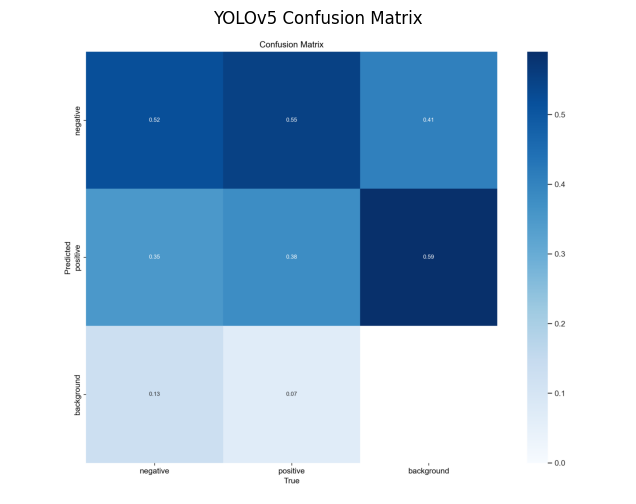

In [9]:
# YOLOv5 auto-generates confusion matrix
cm_path = 'runs/brain_tumor_v5/confusion_matrix.png'
if os.path.exists(cm_path):
    img = mpimg.imread(cm_path)
    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    plt.axis('off')
    plt.title('YOLOv5 Confusion Matrix')
    plt.show()
else:
    print('Confusion matrix not found. This is auto-generated after training.')

## Step 8: Run Validation & Show Detections

In [10]:
!python yolov5/val.py \
    --data yolov5_training.yaml \
    --weights runs/brain_tumor_v5/weights/best.pt \
    --img 640 \
    --device mps \
    --name brain_tumor_v5_val \
    --project runs \
    --save-txt \
    --save-conf \
    --exist-ok

val: data=brain_tumor_yolov5.yaml, weights=['runs/yolov5/brain_tumor_v5/weights/best.pt'], batch_size=32, imgsz=640, conf_thres=0.001, iou_thres=0.6, max_det=300, task=val, device=mps, workers=8, single_cls=False, augment=False, verbose=False, save_txt=True, save_hybrid=False, save_conf=True, save_json=False, project=runs/yolov5, name=brain_tumor_v5_val, exist_ok=True, half=False, dnn=False
YOLOv5 🚀 v7.0-460-g3fb11111 Python-3.11.14 torch-2.10.0 MPS

Fusing layers... 
Model summary: 157 layers, 7015519 parameters, 0 gradients, 15.8 GFLOPs
val: Scanning /Users/hiteshprajapathi/Desktop/brain_tumor/brain_tumor_subset/lab
                 Class     Images  Instances          P          R      mAP50   
                   all        223        241      0.479      0.869      0.527      0.362
              negative        223        154      0.591      0.818       0.59      0.416
              positive        223         87      0.367       0.92      0.464      0.308
Speed: 0.9ms pre-process, 

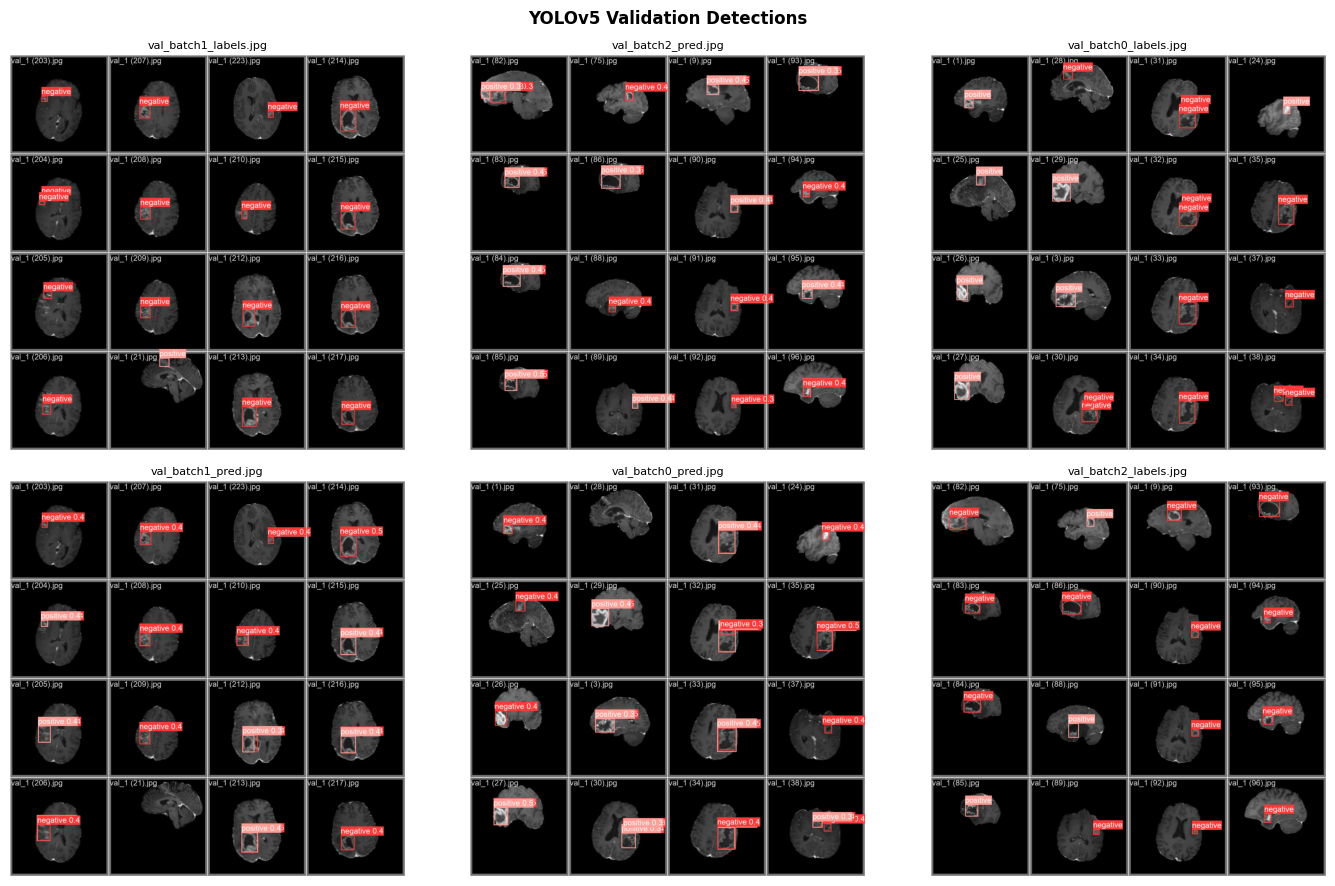

In [11]:
# Show validation detection images
val_imgs = glob('runs/brain_tumor_v5_val/*.jpg')[:6]
if not val_imgs:
    val_imgs = glob('runs/brain_tumor_v5_val/*.png')[:6]

if val_imgs:
    fig, axes = plt.subplots(2, 3, figsize=(14, 9))
    for i, img_path in enumerate(val_imgs):
        ax = axes[i//3][i%3]
        ax.imshow(mpimg.imread(img_path))
        ax.set_title(os.path.basename(img_path), fontsize=8)
        ax.axis('off')
    plt.suptitle('YOLOv5 Validation Detections', fontweight='bold')
    plt.tight_layout()
    plt.savefig('yolov5_val_detections.png', dpi=100)
    plt.show()
else:
    print('No validation images found.')

**Interpretation:** Validation detections show where the model places bounding boxes on unseen images. The confidence score next to each box indicates how sure the model is.

## Step 9: Run Inference on Test Images

In [12]:
# Run detection on validation images as test
!python yolov5/detect.py \
    --weights runs/brain_tumor_v5/weights/best.pt \
    --img 640 \
    --device mps \
    --source brain_tumor_subset/images/val \
    --name brain_tumor_v5_test \
    --project runs \
    --save-txt \
    --save-conf \
    --exist-ok

detect: weights=['runs/yolov5/brain_tumor_v5/weights/best.pt'], source=brain_tumor_subset/images/val, data=yolov5/data/coco128.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=mps, view_img=False, save_txt=True, save_format=0, save_csv=False, save_conf=True, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/yolov5, name=brain_tumor_v5_test, exist_ok=True, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-460-g3fb11111 Python-3.11.14 torch-2.10.0 MPS

Fusing layers... 
Model summary: 157 layers, 7015519 parameters, 0 gradients, 15.8 GFLOPs
image 1/223 /Users/hiteshprajapathi/Desktop/brain_tumor/brain_tumor_subset/images/val/val_1 (1).jpg: 640x640 1 negative, 1 positive, 16.4ms
image 2/223 /Users/hiteshprajapathi/Desktop/brain_tumor/brain_tumor_subset/images/val/val_1 (10).jpg: 640x640 1 negative, 19.2ms
image 3/223 /Users/hiteshpraj

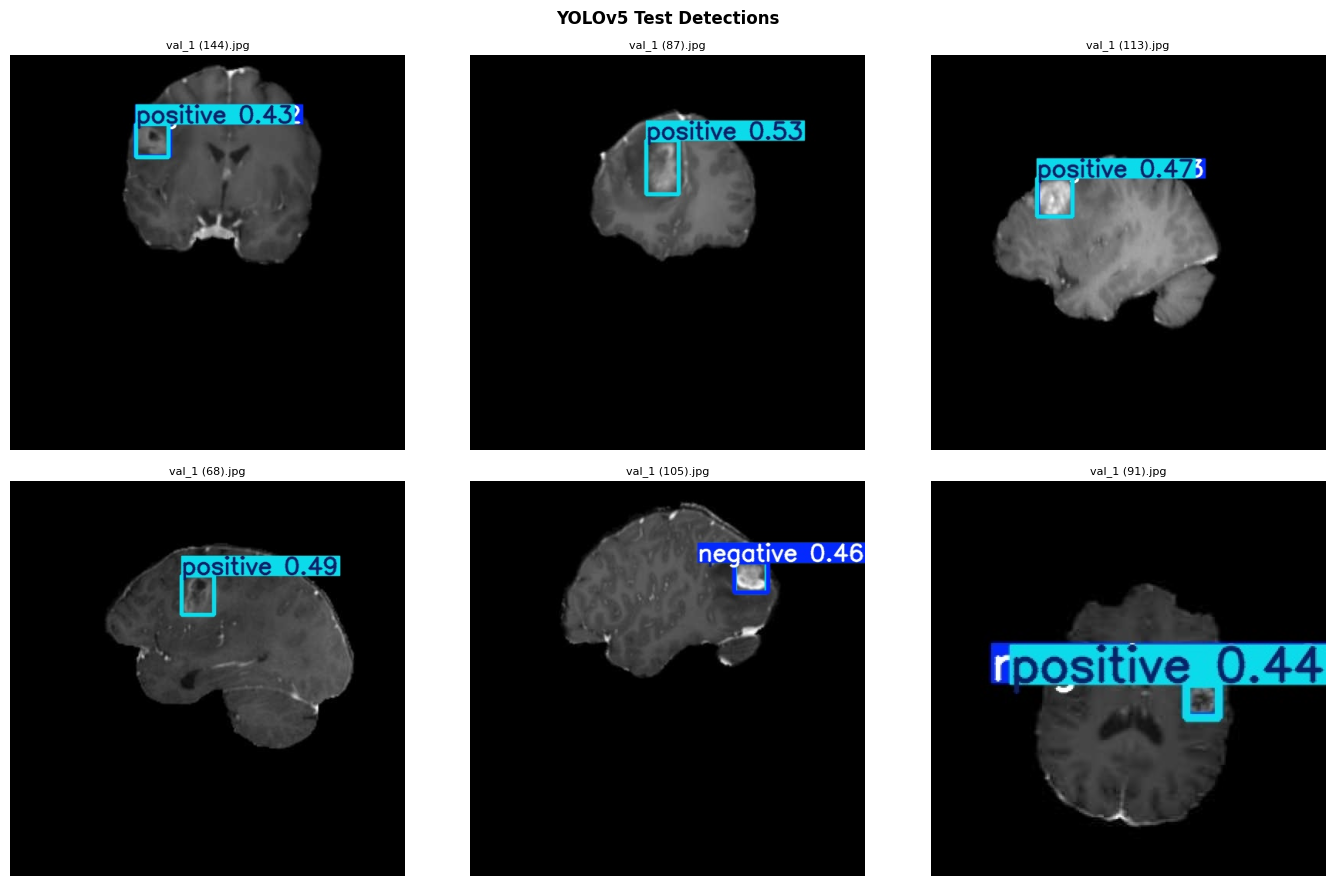


Best weights saved at: runs/yolov5/brain_tumor_v5/weights/best.pt
YOLOv5 training and evaluation complete!


In [13]:
# Show test detection results
test_results = glob('runs/brain_tumor_v5_test/*.jpg')[:6]

if test_results:
    fig, axes = plt.subplots(2, 3, figsize=(14, 9))
    for i, img_path in enumerate(test_results):
        ax = axes[i//3][i%3]
        ax.imshow(mpimg.imread(img_path))
        ax.set_title(os.path.basename(img_path), fontsize=8)
        ax.axis('off')
    plt.suptitle('YOLOv5 Test Detections', fontweight='bold')
    plt.tight_layout()
    plt.savefig('yolov5_test_detections.png', dpi=100)
    plt.show()

print(f"\nBest weights saved at: runs/brain_tumor_v5/weights/best.pt")
print('YOLOv5 training and evaluation complete!')

**Interpretation:** The test detections show the model's predictions on images it has never seen. Bounding boxes around brain regions with confidence scores demonstrate the model's detection capability.